<a href="https://colab.research.google.com/github/ranabarbara1/fraud-detection-transactions-python.ipynb/blob/main/Projeto__Detec%C3%A7%C3%A3o_de_Anomalias_em_Transa%C3%A7%C3%B5es_em_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carregando os dados

In [2]:
import pandas as pd

In [3]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Problema de classificação desbalanceada

Fraudes são raras -> modelo pode ignorar a classe 1

In [5]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


# Feature Engineering

Criando variáveis que ajudam o modelo

In [8]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Accuracy pode ser alta mesmo sem detectar fraudes.
Por isso usamos:

*   Recall (mais importante)
*   Precision
*   F1-score

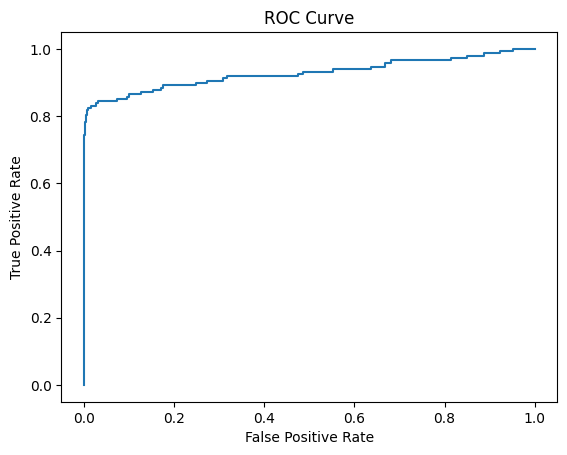

AUC: 0.9272042339543365


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

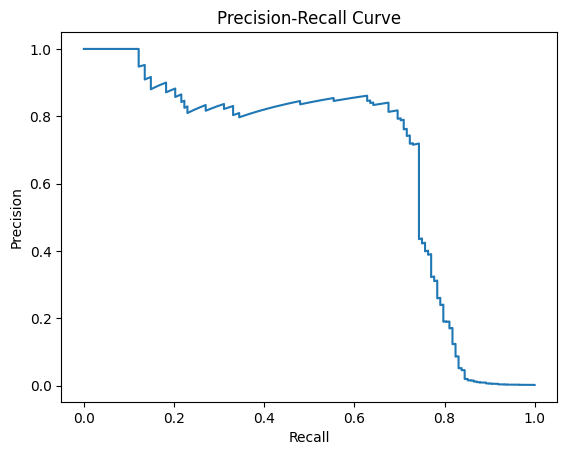

In [14]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Balanceamento de Dados

In [15]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [16]:
# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [18]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [19]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



# Modelo Avançado - XGBoost


XGBoost é um dos algoritmos mais usados em competições e mercado.
Ele é mais poderoso que Random Forest para muitos problemas.

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,  # ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:24:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [22]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



# Importância das Variáveis

Ajuda a entender quais variáveis influenciam mais o modelo

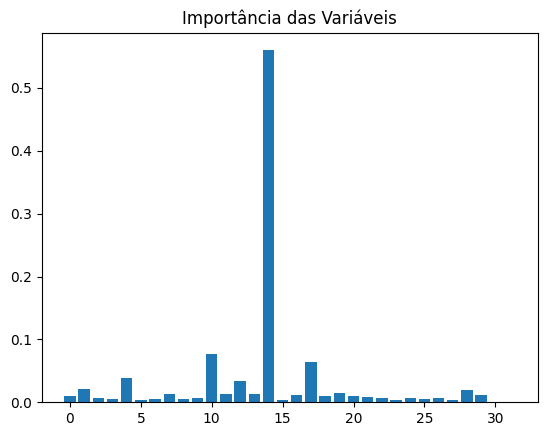

In [27]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)),importancias)
plt.title("Importância das Variáveis")
plt.show()

# Ajuste de Hiperparâmetros

Testamos várias combinações para melhorar o modelo

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 3, 'n_estimators': 100}


# Explicabilidade (SHAP)

SHAP mostra como cada variável influencia a decisão do modelo

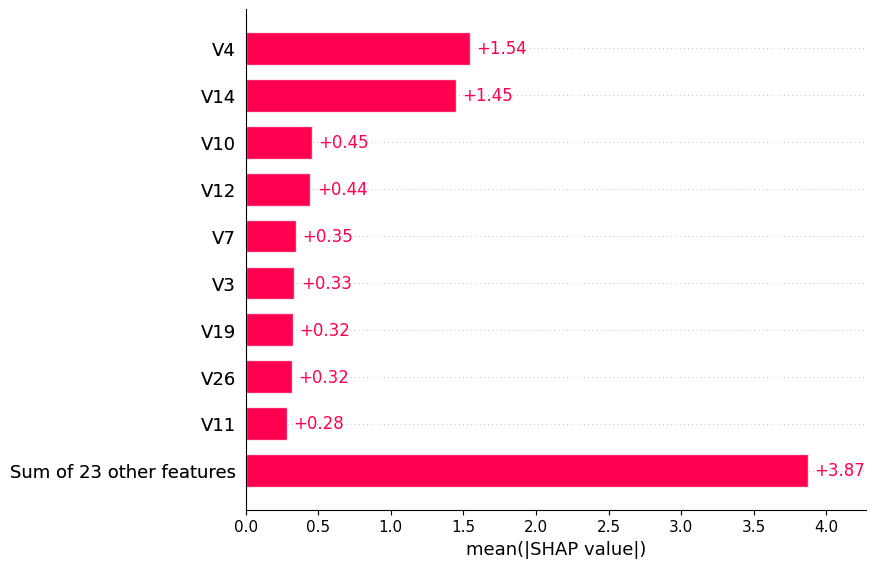

In [26]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

# Análise de Threshold

Em problemas de detecção de fraude, o threshold padrão de 0.5 nem sempre é a melhor escolha.

Thresholds menores tendem a aumentar a detecção de fraudes (Recall), enquanto thresholds maiores reduzem falsos positivos (aumentam a Precision).

Nesta seção, avaliamos o comportamento do modelo para diferentes valores de threshold.

In [28]:
best_xgb = grid.best_estimator_

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

y_prob = best_xgb.predict_proba(X_test)[:,1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

resultados = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    resultados.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

df_threshold = pd.DataFrame(resultados)

df_threshold

,Threshold,Precision,Recall,F1-Score
0,0.1,0.721519,0.770270,0.745098
1,0.3,0.818841,0.763514,0.790210
2,0.5,0.862595,0.763514,0.810036
3,0.7,0.888889,0.756757,0.817518
4,0.9,0.922414,0.722973,0.810606


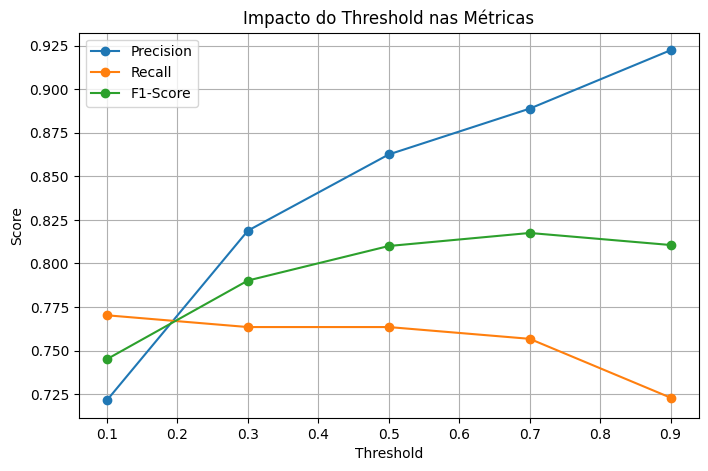

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    df_threshold["Threshold"],
    df_threshold["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    df_threshold["Threshold"],
    df_threshold["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    df_threshold["Threshold"],
    df_threshold["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Impacto do Threshold nas Métricas")

plt.legend()
plt.grid(True)

plt.show()

- Conclusões da Análise de Threshold

Os resultados mostram o impacto da escolha do threshold no desempenho do modelo.

À medida que o threshold aumenta, a Precision cresce de 72,15% para 92,24%, indicando uma redução na quantidade de falsos positivos. Em contrapartida, o Recall diminui de 77,03% para 72,30%, o que significa que mais fraudes deixam de ser identificadas.

O melhor equilíbrio entre Precision e Recall foi obtido com threshold igual a 0.7, que apresentou o maior F1-Score (81,75%). Dessa forma, para este conjunto de dados, valores próximos de 0.7 parecem oferecer uma relação mais adequada entre detecção de fraudes e redução de alertas incorretos.

A escolha final do threshold depende do contexto do negócio. Em cenários onde perder uma fraude é mais custoso do que investigar um falso positivo, thresholds menores podem ser preferíveis. Já em ambientes que exigem maior precisão nas detecções, thresholds mais elevados podem ser mais adequados.

# Impacto no Negócio

A detecção de fraudes é um problema crítico para instituições financeiras, pois transações fraudulentas podem gerar prejuízos financeiros, danos à reputação e perda de confiança dos clientes.

Os resultados obtidos mostram que o modelo é capaz de identificar uma parcela significativa das fraudes, mantendo um equilíbrio entre Precision e Recall. A análise de threshold demonstrou que diferentes configurações podem ser adotadas de acordo com os objetivos da organização.

Em cenários onde o custo de uma fraude não detectada é elevado, pode ser interessante utilizar thresholds menores para aumentar o Recall, mesmo que isso gere mais falsos positivos. Por outro lado, quando o custo de investigação é alto, thresholds maiores podem ser utilizados para aumentar a Precision.

Dessa forma, o modelo desenvolvido pode servir como ferramenta de apoio à tomada de decisão, auxiliando equipes de prevenção a fraudes na priorização de transações suspeitas para análise.

In [31]:
from sklearn.metrics import confusion_matrix

y_pred = (y_prob >= 0.7).astype(int)

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print(f"Fraudes detectadas: {tp}")
print(f"Fraudes não detectadas: {fn}")

Fraudes detectadas: 112
Fraudes não detectadas: 36


A detecção de fraudes é um desafio importante para instituições financeiras, pois transações fraudulentas podem gerar perdas financeiras e comprometer a confiança dos clientes.

Utilizando o threshold de 0.7, o modelo foi capaz de identificar 112 das 148 fraudes presentes no conjunto de teste, correspondendo a aproximadamente 75,7% dos casos fraudulentos.

Embora 36 fraudes não tenham sido detectadas, os resultados demonstram que o modelo possui potencial para atuar como ferramenta de apoio na identificação de transações suspeitas, permitindo que equipes de prevenção concentrem seus esforços nos casos com maior probabilidade de fraude.

Além disso, a análise de threshold mostrou que a escolha do limiar de classificação influencia diretamente o equilíbrio entre detecção de fraudes e ocorrência de falsos positivos. Dessa forma, o threshold pode ser ajustado de acordo com as necessidades e estratégias da organização.

Em um ambiente real, uma solução desse tipo poderia contribuir para a redução de perdas financeiras, aumento da eficiência operacional e melhoria dos processos de monitoramento de transações.